# XAI Analysis — Combined TF-IDF + NRC MLP Model

Explainability analysis for the `reddit_mlp_hyperband_v2.keras` model trained on combined TF-IDF (5000) + NRC emotion (10) features.

**Method:** SHAP (SHapley Additive exPlanations) — global & local feature importance


## 1. Setup & Imports

In [3]:
!uv pip install "shap==0.47.0" "numpy<2" --quiet


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from os import path
from scipy.sparse import load_npz
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
import tensorflow as tf
import shap
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow: {tf.__version__}")
print(f"SHAP: {shap.__version__}")


TensorFlow: 2.16.1
SHAP: 0.47.0


## 2. Load Data & Model

In [5]:
# ── Config ──────────────────────────────────────────────────────────────────
DATA_DIR        = 'processed_dirty'
MODEL_PATH      = 'models/reddit_mlp_hyperband_v2.keras'
RANDOM_STATE    = 42
TEST_SIZE       = 0.2
SHAP_BG_SAMPLES = 100   # background samples for SHAP (keep low to save RAM)
SHAP_TEST_SAMPLES = 200 # samples to explain

# NRC emotion column order matches NRCLex raw_emotion_scores (alphabetical)
NRC_EMOTION_NAMES = [
    'anger', 'anticipation', 'disgust', 'fear',
    'joy', 'negative', 'positive', 'sadness', 'surprise', 'trust'
]
N_TFIDF = 5000
N_NRC   = len(NRC_EMOTION_NAMES)

# ── Load sparse combined matrix + labels ────────────────────────────────────
X_combined = load_npz(path.join(DATA_DIR, 'X_combined_sparse.npz'))
y           = np.load(path.join(DATA_DIR, 'y.npy'))
y_series    = pd.Series(y)

print(f"X_combined shape : {X_combined.shape}")
print(f"y shape          : {y_series.shape}")
print(f"Class distribution:\n{y_series.value_counts()}")


X_combined shape : (99590, 5010)
y shape          : (99590,)
Class distribution:
0    58405
1    41185
Name: count, dtype: int64


In [6]:
# Reproduce the exact same train/test split used in combined_tensor.ipynb
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_combined, y_series, test_size=TEST_SIZE, stratify=y_series, random_state=RANDOM_STATE
)

# Oversample training split (same as training notebook)
ros = RandomOverSampler(random_state=RANDOM_STATE)
X_train_val_res, y_train_val_res = ros.fit_resample(X_train_val, y_train_val)

# Build feature name array:  tfidf_0 … tfidf_4999 | anger … trust
feature_names = (
    [f'tfidf_{i}' for i in range(N_TFIDF)] + NRC_EMOTION_NAMES
)
feature_names = np.array(feature_names)

print(f"Train/val (resampled) : {X_train_val_res.shape}")
print(f"Test                  : {X_test.shape}")
print(f"Feature names         : {len(feature_names)}  ({N_TFIDF} TF-IDF + {N_NRC} NRC)")

# Load pretrained model
model = tf.keras.models.load_model(MODEL_PATH)
model.summary()


Train/val (resampled) : (93448, 5010)
Test                  : (19918, 5010)
Feature names         : 5010  (5000 TF-IDF + 10 NRC)


2026-03-02 22:52:37.347089: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-02 22:52:37.347128: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-02 22:52:37.347136: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-02 22:52:37.347169: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-02 22:52:37.347179: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 416)            │     2,084,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 416)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 192)            │        80,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,329,668 (16.52 MB)

 Trainable params: 2,164,833 (8.26 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,164,835 (8.26 MB)

## 3. SHAP — Global Feature Importance

`DeepExplainer` approximates Shapley values using a small background dataset sampled from the training set.

In [7]:
np.random.seed(RANDOM_STATE)

# Sample background dataset from resampled training data (dense)
bg_idx = np.random.choice(X_train_val_res.shape[0], size=SHAP_BG_SAMPLES, replace=False)
X_background = X_train_val_res[bg_idx].toarray().astype(np.float32)

# Sample test instances to explain (dense)
test_idx = np.random.choice(X_test.shape[0], size=SHAP_TEST_SAMPLES, replace=False)
X_explain = X_test[test_idx].toarray().astype(np.float32)
y_explain  = y_test.iloc[test_idx].values

print(f"Background samples : {X_background.shape}")
print(f"Explain samples    : {X_explain.shape}")

# Build SHAP DeepExplainer
explainer = shap.DeepExplainer(model, X_background)

print("Computing SHAP values … (this may take a minute)")
shap_values = explainer.shap_values(X_explain)   # list of arrays for each output

# For binary sigmoid output, shap_values is a list with one element
if isinstance(shap_values, list):
    sv = shap_values[0]   # shape (n_samples, n_features)
else:
    sv = shap_values

sv = np.squeeze(sv)   # ensure 2-D: (n_samples, n_features)
print(f"SHAP values shape  : {sv.shape}")


Background samples : (100, 5010)
Explain samples    : (200, 5010)
Computing SHAP values … (this may take a minute)


2026-03-02 22:52:38.512239: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


SHAP values shape  : (200, 5010)


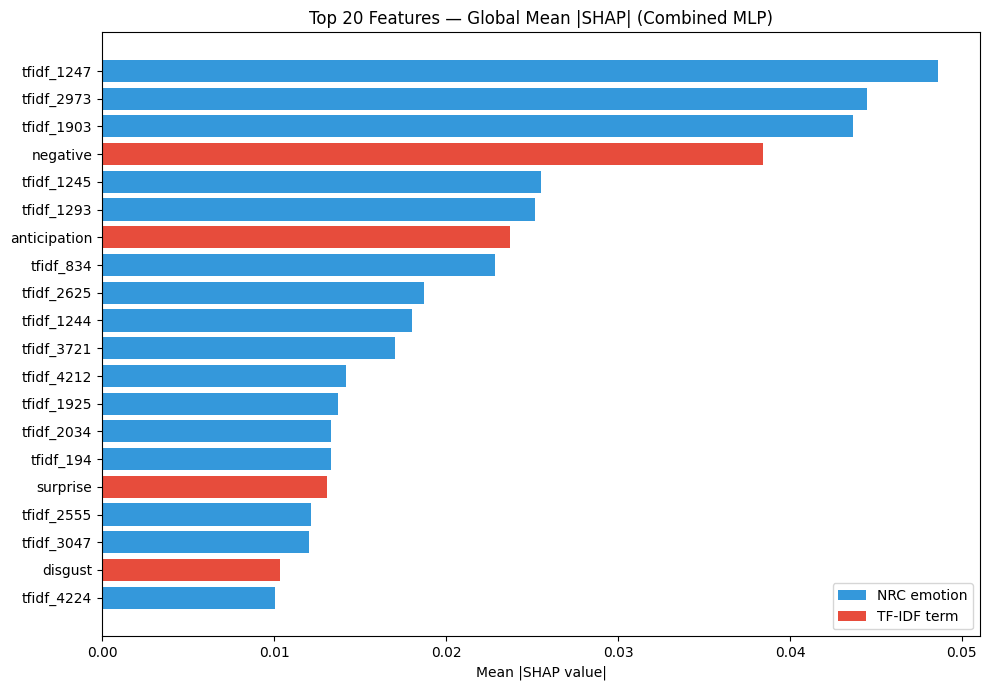


Top 20 features:
   1. tfidf_1247                      mean|SHAP|=0.04862  [TF-IDF]
   2. tfidf_2973                      mean|SHAP|=0.04449  [TF-IDF]
   3. tfidf_1903                      mean|SHAP|=0.04366  [TF-IDF]
   4. negative                        mean|SHAP|=0.03843  [NRC]
   5. tfidf_1245                      mean|SHAP|=0.02554  [TF-IDF]
   6. tfidf_1293                      mean|SHAP|=0.02515  [TF-IDF]
   7. anticipation                    mean|SHAP|=0.02373  [NRC]
   8. tfidf_834                       mean|SHAP|=0.02288  [TF-IDF]
   9. tfidf_2625                      mean|SHAP|=0.01873  [TF-IDF]
  10. tfidf_1244                      mean|SHAP|=0.01803  [TF-IDF]
  11. tfidf_3721                      mean|SHAP|=0.01706  [TF-IDF]
  12. tfidf_4212                      mean|SHAP|=0.01421  [TF-IDF]
  13. tfidf_1925                      mean|SHAP|=0.01371  [TF-IDF]
  14. tfidf_2034                      mean|SHAP|=0.01332  [TF-IDF]
  15. tfidf_194                       mean|SHAP|=0

In [8]:
### 3.1 Summary Bar Plot — Top 20 Features (global mean |SHAP|)

mean_abs_shap = np.abs(sv).mean(axis=0)          # (n_features,)
top20_idx     = np.argsort(mean_abs_shap)[::-1][:20]

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if i >= N_TFIDF else '#3498db' for i in top20_idx]
ax.barh(feature_names[top20_idx][::-1], mean_abs_shap[top20_idx][::-1], color=colors[::-1])
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Top 20 Features — Global Mean |SHAP| (Combined MLP)')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498db', label='NRC emotion'),
                   Patch(facecolor='#e74c3c', label='TF-IDF term')]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()
print("\nTop 20 features:")
for rank, i in enumerate(top20_idx, 1):
    ftype = 'NRC' if i >= N_TFIDF else 'TF-IDF'
    print(f"  {rank:2d}. {feature_names[i]:30s}  mean|SHAP|={mean_abs_shap[i]:.5f}  [{ftype}]")


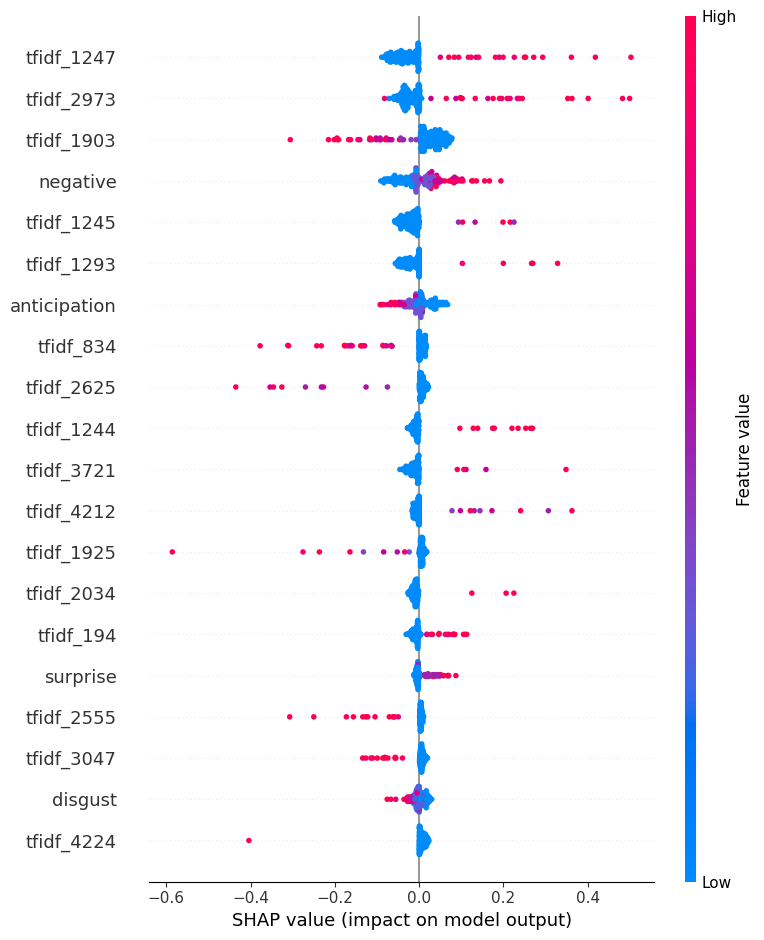

In [9]:
### 3.2 SHAP Beeswarm (Summary) Plot — Top 20 Features

shap.summary_plot(
    sv[:, top20_idx],
    features=X_explain[:, top20_idx],
    feature_names=feature_names[top20_idx],
    max_display=20,
    show=True,
    plot_type='dot'
)


## 4. NRC Emotion Feature Deep-Dive

Isolate the 10 NRC emotion features and examine their SHAP contribution split by class.

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
     Emotion  SHAP (depression)  SHAP (non-dep)  mean |SHAP|
    negative           0.042978       -0.022976     0.038429
anticipation           0.021454       -0.013359     0.023733
    surprise           0.011894        0.001728     0.013092
     disgust           0.005999       -0.006257     0.010344
         joy          -0.008422        0.006418     0.009893
    positive           0.001310        0.003575     0.009541
       anger           0.003736       -0.000676     0.007205
        fear           0.005619       -0.003366     0.006868
       trust          -0.000217       -0.000863     0.005862
     sadness          -0.001038        0.001509     0.005608


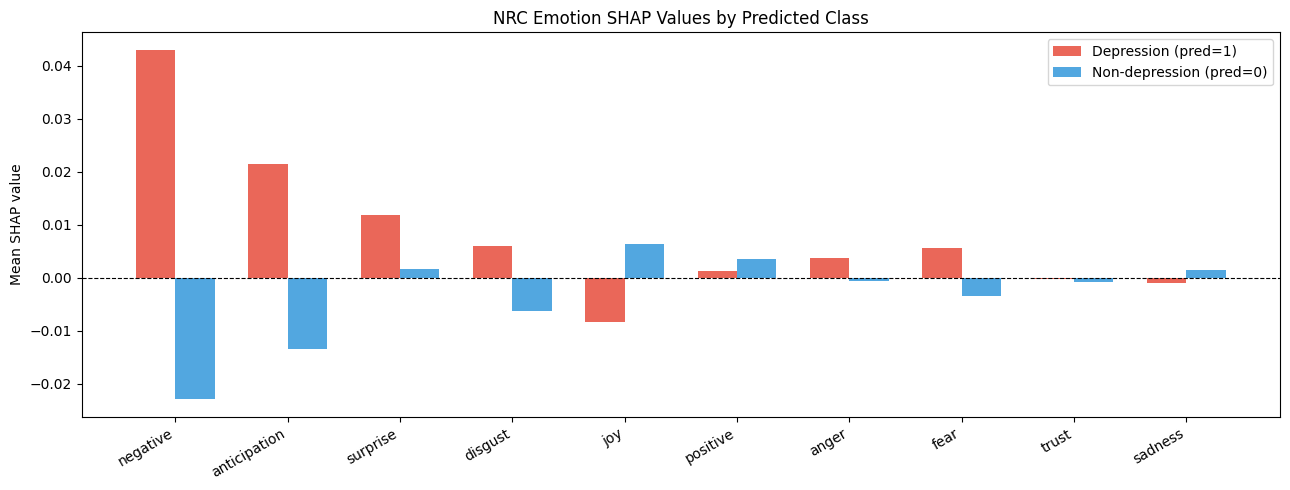

In [10]:
### 4.1 NRC SHAP values — mean by class

nrc_sv = sv[:, N_TFIDF:]           # (n_samples, 10)
nrc_X  = X_explain[:, N_TFIDF:]    # (n_samples, 10) — actual NRC feature values

# Mean SHAP split by predicted class
pred_probs = model.predict(X_explain).flatten()
pred_class = (pred_probs >= 0.5).astype(int)

nrc_mean_dep     = nrc_sv[pred_class == 1].mean(axis=0)
nrc_mean_nodep   = nrc_sv[pred_class == 0].mean(axis=0)

nrc_df = pd.DataFrame({
    'Emotion': NRC_EMOTION_NAMES,
    'SHAP (depression)': nrc_mean_dep,
    'SHAP (non-dep)':    nrc_mean_nodep,
    'mean |SHAP|':       np.abs(nrc_sv).mean(axis=0)
}).sort_values('mean |SHAP|', ascending=False)

print(nrc_df.to_string(index=False))

# Grouped bar chart
x   = np.arange(len(NRC_EMOTION_NAMES))
w   = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
sorted_emotions = nrc_df['Emotion'].tolist()
dep_vals   = nrc_df['SHAP (depression)'].values
nodep_vals = nrc_df['SHAP (non-dep)'].values

bars1 = ax.bar(x - w/2, dep_vals,   w, label='Depression (pred=1)', color='#e74c3c', alpha=0.85)
bars2 = ax.bar(x + w/2, nodep_vals, w, label='Non-depression (pred=0)', color='#3498db', alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(sorted_emotions, rotation=30, ha='right')
ax.set_ylabel('Mean SHAP value')
ax.set_title('NRC Emotion SHAP Values by Predicted Class')
ax.legend()
plt.tight_layout()
plt.show()


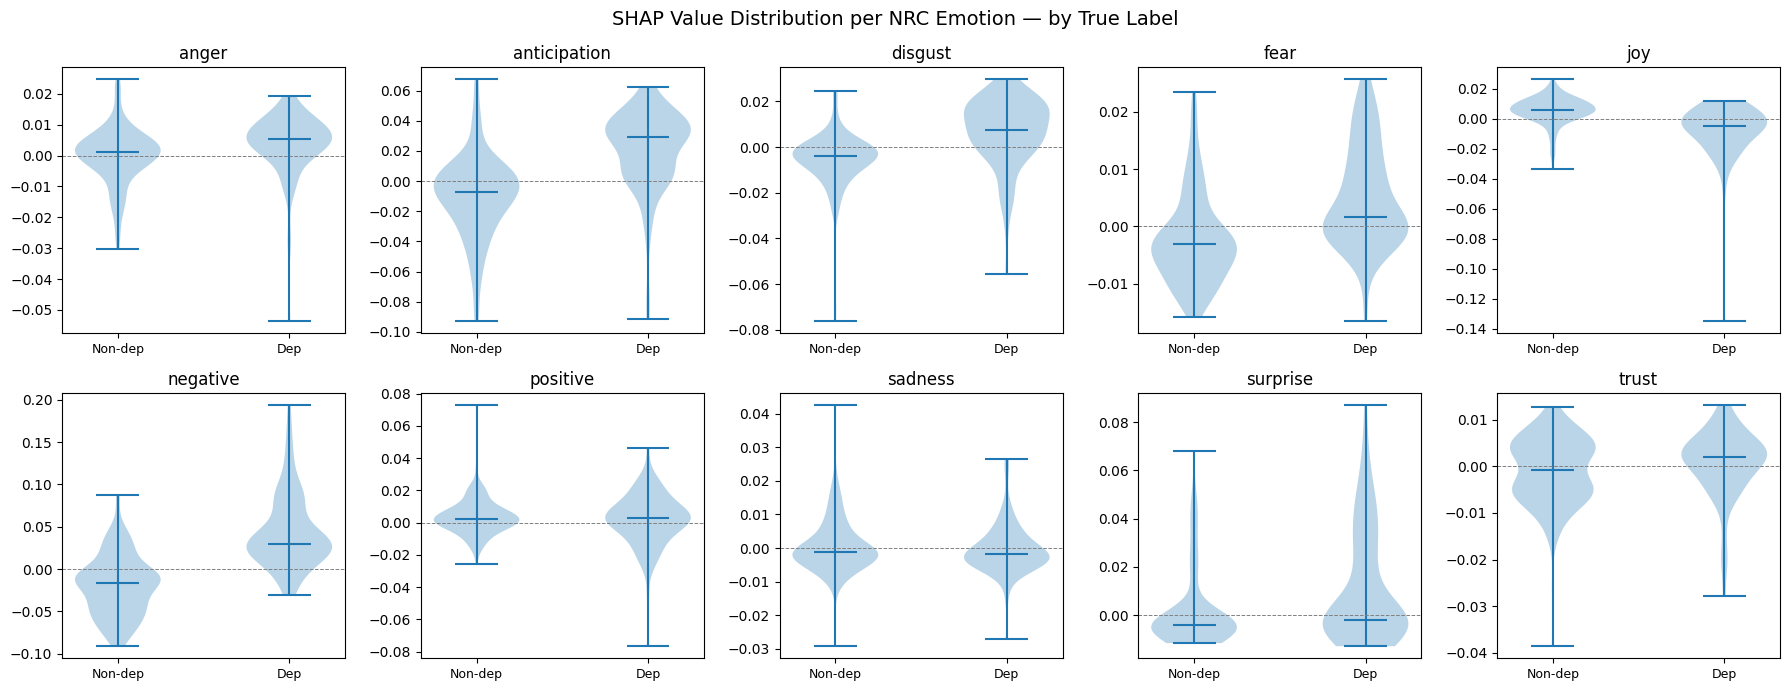

In [11]:
### 4.2 Violin Plot — NRC SHAP distribution by true label

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
for idx, emotion in enumerate(NRC_EMOTION_NAMES):
    dep_shap   = nrc_sv[y_explain == 1, idx]
    nodep_shap = nrc_sv[y_explain == 0, idx]
    axes[idx].violinplot([nodep_shap, dep_shap], showmedians=True)
    axes[idx].set_xticks([1, 2])
    axes[idx].set_xticklabels(['Non-dep', 'Dep'], fontsize=9)
    axes[idx].set_title(emotion)
    axes[idx].axhline(0, color='grey', linestyle='--', linewidth=0.7)

fig.suptitle('SHAP Value Distribution per NRC Emotion — by True Label', fontsize=14)
plt.tight_layout()
plt.show()


## 5. SHAP — Local Explanations (Individual Predictions)

Waterfall plots show how each feature pushes a single prediction away from the base value.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step


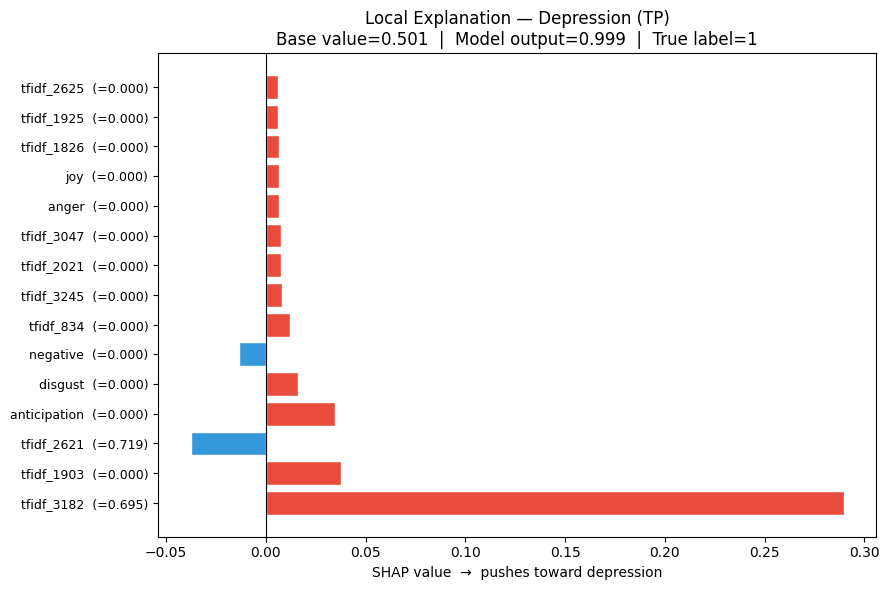

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


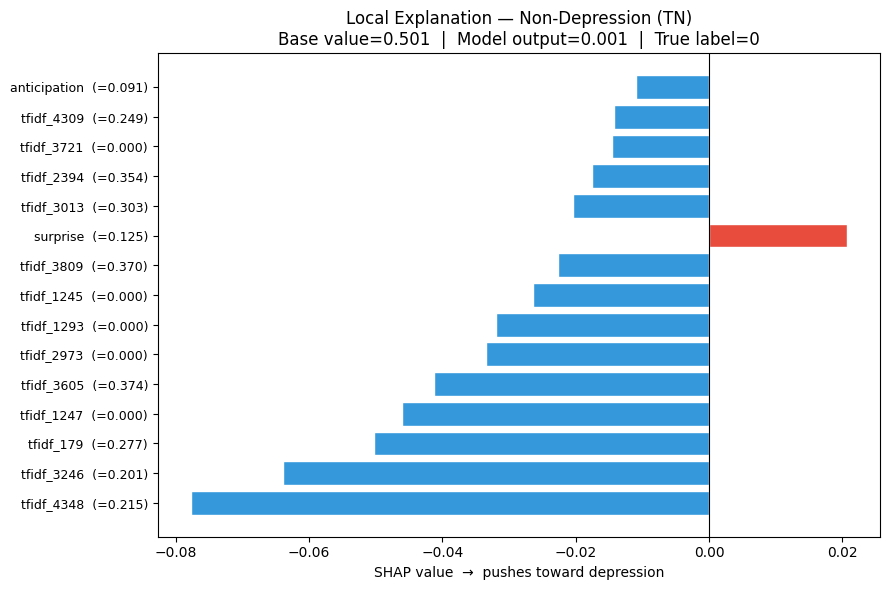

In [12]:
### 5.1 Waterfall plots — one depression & one non-depression sample

def plot_waterfall(sample_idx: int, title: str, n_top: int = 15):
    """Plot a SHAP waterfall chart for a single test sample."""
    shap_row = sv[sample_idx]
    feat_vals = X_explain[sample_idx]

    # Sort by absolute SHAP magnitude, keep top-n
    order    = np.argsort(np.abs(shap_row))[::-1][:n_top]
    names    = feature_names[order]
    vals     = shap_row[order]
    fvals    = feat_vals[order]

    base_val = float(explainer.expected_value[0]) if isinstance(
        explainer.expected_value, (list, np.ndarray)) else float(explainer.expected_value)
    pred_val = float(model.predict(X_explain[[sample_idx]])[0][0])

    fig, ax = plt.subplots(figsize=(9, 6))
    colors  = ['#e74c3c' if v > 0 else '#3498db' for v in vals]
    y_pos   = np.arange(len(names))
    ax.barh(y_pos, vals, color=colors, edgecolor='white')
    ax.set_yticks(y_pos)
    ax.set_yticklabels([f'{n}  (={fv:.3f})' for n, fv in zip(names, fvals)], fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('SHAP value  →  pushes toward depression')
    ax.set_title(f'{title}\nBase value={base_val:.3f}  |  Model output={pred_val:.3f}  |  True label={y_explain[sample_idx]}')
    plt.tight_layout()
    plt.show()

# Pick one confident depression and one confident non-depression prediction
dep_idxs   = np.where((pred_class == 1) & (y_explain == 1))[0]
nodep_idxs = np.where((pred_class == 0) & (y_explain == 0))[0]

if len(dep_idxs) > 0:
    dep_conf_idx = dep_idxs[np.argmax(pred_probs[dep_idxs])]
    plot_waterfall(dep_conf_idx, 'Local Explanation — Depression (TP)')

if len(nodep_idxs) > 0:
    nodep_conf_idx = nodep_idxs[np.argmin(pred_probs[nodep_idxs])]
    plot_waterfall(nodep_conf_idx, 'Local Explanation — Non-Depression (TN)')


False Positives: 13  |  False Negatives: 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


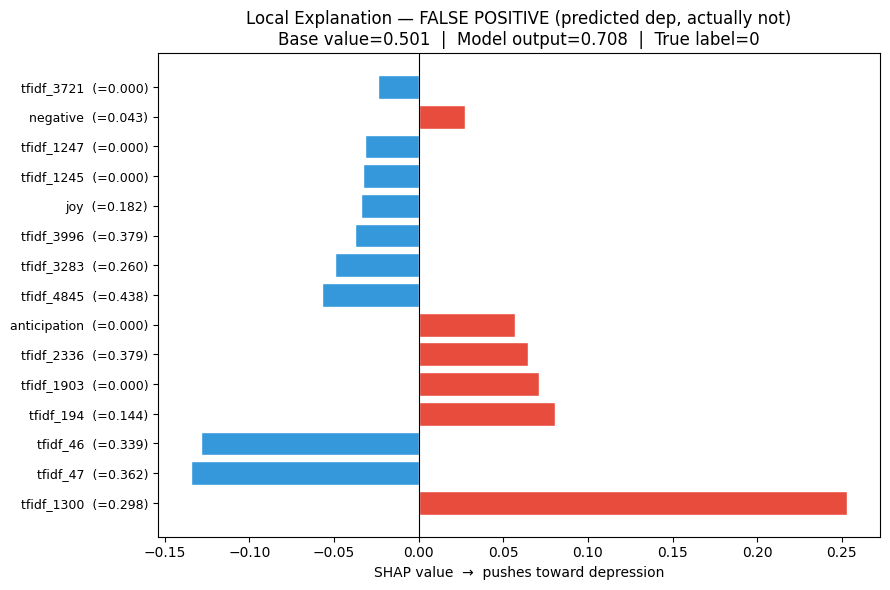

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


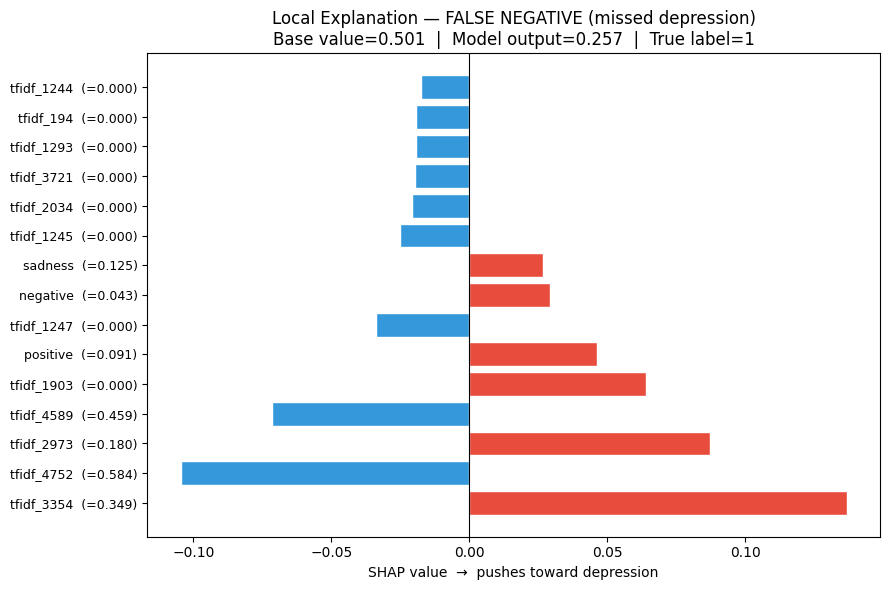

In [13]:
### 5.2 Misclassifications — explaining false positives & false negatives

fp_idxs = np.where((pred_class == 1) & (y_explain == 0))[0]   # False Positive
fn_idxs = np.where((pred_class == 0) & (y_explain == 1))[0]   # False Negative

print(f"False Positives: {len(fp_idxs)}  |  False Negatives: {len(fn_idxs)}")

if len(fp_idxs) > 0:
    plot_waterfall(fp_idxs[0], 'Local Explanation — FALSE POSITIVE (predicted dep, actually not)')

if len(fn_idxs) > 0:
    plot_waterfall(fn_idxs[0], 'Local Explanation — FALSE NEGATIVE (missed depression)')
